# World Bank Economic Analysis - Project

**The situation**

You have just been hired as a Data Journalists for the Numbers, a magazine that focuses on global economic news and issues

**The assingment**

The World Bank has just released its annuals economic report, which includes data on every contrys economy and development statistics.
You have been asked to produce an infographic -style report highlighthing major trends in global economic growth and development.

**The objectives**
1. QA and Profile the World Bank data, and join additiona UN Data to it
2. Prepare and reormat the data for visualization
3. Create Visualizations that depict key trends and relationships in the data
4. Combine your visualizations into a single report style graphic

# The Data Set

**Economic development data from the World Bank and the United Nation**

**File type** - Excel

**Data infrastructure** - Multiple tables

**# of records** - 12.657

**# of fields** - 58

# Objective 1 - Prepare & QA the Data

## Task 1 - Import the World Bank Excel file.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
world_bank_data = pd.read_excel('WorldBank.xlsx', sheet_name="Development Indicators")

world_bank_data.head()

,Country Name,Country Code,Region,IncomeGroup,Year,"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)",Electric power consumption (kWh per capita),GDP (USD),GDP per capita (USD),Individuals using the Internet (% of population),"Infant mortality rate (per 1,000 live births)",Life expectancy at birth (years),Population density (people per sq. km of land area),Unemployment (% of total labor force) (modeled ILO estimate)
0,Afghanistan,AFG,South Asia,Low income,2018,NaN,NaN,NaN,1.936300e+10,520.897,NaN,47.9,NaN,56.9378,1.542
1,Afghanistan,AFG,South Asia,Low income,2017,33.211,6.575,NaN,2.019180e+10,556.302,13.50,49.5,64.130,55.5960,1.559
2,Afghanistan,AFG,South Asia,Low income,2016,33.981,6.742,NaN,1.936260e+10,547.228,11.20,51.2,63.763,54.1971,1.634
3,Afghanistan,AFG,South Asia,Low income,2015,34.809,6.929,NaN,1.990710e+10,578.466,8.26,53.1,63.377,52.7121,1.679
4,Afghanistan,AFG,South Asia,Low income,2014,35.706,7.141,NaN,2.048490e+10,613.856,7.00,55.1,62.966,51.1148,1.735


## Task 2 - Use "GDP" and "GDP per Capita" to calculate population in millions and create a "Population (M)" column.

In [3]:
world_bank_data = world_bank_data.assign(
    Population = (world_bank_data['GDP (USD)'] / world_bank_data['GDP per capita (USD)'])/1_000_000
)

world_bank_data.head()

,Country Name,Country Code,Region,IncomeGroup,Year,"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)",Electric power consumption (kWh per capita),GDP (USD),GDP per capita (USD),Individuals using the Internet (% of population),"Infant mortality rate (per 1,000 live births)",Life expectancy at birth (years),Population density (people per sq. km of land area),Unemployment (% of total labor force) (modeled ILO estimate),Population
0,Afghanistan,AFG,South Asia,Low income,2018,NaN,NaN,NaN,1.936300e+10,520.897,NaN,47.9,NaN,56.9378,1.542,37.172416
1,Afghanistan,AFG,South Asia,Low income,2017,33.211,6.575,NaN,2.019180e+10,556.302,13.50,49.5,64.130,55.5960,1.559,36.296472
2,Afghanistan,AFG,South Asia,Low income,2016,33.981,6.742,NaN,1.936260e+10,547.228,11.20,51.2,63.763,54.1971,1.634,35.383058
3,Afghanistan,AFG,South Asia,Low income,2015,34.809,6.929,NaN,1.990710e+10,578.466,8.26,53.1,63.377,52.7121,1.679,34.413604
4,Afghanistan,AFG,South Asia,Low income,2014,35.706,7.141,NaN,2.048490e+10,613.856,7.00,55.1,62.966,51.1148,1.735,33.370856


## Task 3 - Perform basic profiling & QA on the data.

In [4]:
world_bank_data.describe()

,Year,"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)",Electric power consumption (kWh per capita),GDP (USD),GDP per capita (USD),Individuals using the Internet (% of population),"Infant mortality rate (per 1,000 live births)",Life expectancy at birth (years),Population density (people per sq. km of land area),Unemployment (% of total labor force) (modeled ILO estimate),Population
count,12449.00000,11440.000000,11416.000000,5848.000000,9.578000e+03,9575.000000,5064.000000,9984.000000,11176.000000,11845.000000,5208.000000,9575.000000
mean,1989.00000,28.643276,10.588539,3175.294686,1.700740e+11,8231.812259,23.334471,51.704437,64.044692,318.861370,8.295079,29.956728
std,17.03007,13.131893,5.489382,4467.139298,8.979866e+11,16173.539954,28.319388,46.131039,11.491087,1593.406041,6.290703,115.803824
min,1960.00000,6.900000,1.127000,0.000000,8.824450e+06,34.790600,0.000000,1.400000,18.907000,0.098625,0.140000,0.008913
25%,1974.00000,16.600000,6.863750,390.385750,1.393010e+09,513.145500,0.594949,14.475000,55.917750,19.783400,3.687000,1.051937
50%,1989.00000,27.545500,9.200000,1541.895000,7.275305e+09,1852.810000,8.406225,37.000000,67.276000,64.007500,6.775000,5.390515
75%,2004.00000,40.881250,12.687000,4313.767500,4.857782e+10,7774.565000,41.295950,78.200000,72.692250,144.823000,11.212250,17.075158
max,2018.00000,58.227000,54.444000,54799.200000,2.050000e+13,189171.000000,100.000000,279.400000,85.417100,21389.100000,37.940000,1391.895280


In [5]:
world_bank_data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12449 entries, 0 to 12448
Data columns (total 16 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Country Name                                                  12449 non-null  object 
 1   Country Code                                                  12449 non-null  object 
 2   Region                                                        12449 non-null  object 
 3   IncomeGroup                                                   12449 non-null  object 
 4   Year                                                          12449 non-null  int64  
 5   Birth rate, crude (per 1,000 people)                          11440 non-null  float64
 6   Death rate, crude (per 1,000 people)                          11416 non-null  float64
 7   Electric power consumption (kWh per capita)                   5848 

## Task 4 - Filter the data to 2014 and join it with the HDI csv file on "Country Code".

In [6]:
country = pd.read_csv('HDI.csv')
country.head()

,iso3,country,hdicode,region,hdi_rank_2021,hdi_1990,hdi_1991,hdi_1992,hdi_1993,hdi_1994,...,mf_2012,mf_2013,mf_2014,mf_2015,mf_2016,mf_2017,mf_2018,mf_2019,mf_2020,mf_2021
0,AFG,Afghanistan,Low,SA,180.0,0.273,0.279,0.287,0.297,0.292,...,1.86,1.88,1.66,1.62,1.66,1.41,1.32,1.38,1.38,1.38
1,AGO,Angola,Medium,SSA,148.0,NaN,NaN,NaN,NaN,NaN,...,4.09,4.53,3.97,3.59,2.79,2.64,2.28,2.18,2.18,2.18
2,ALB,Albania,High,ECA,67.0,0.647,0.629,0.614,0.617,0.624,...,12.44,11.49,13.14,12.61,14.39,14.46,12.85,12.96,12.96,12.96
3,AND,Andorra,Very High,NaN,40.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ARE,United Arab Emirates,Very High,AS,26.0,0.728,0.739,0.742,0.748,0.755,...,49.56,49.68,55.49,59.76,64.95,75.61,65.97,68.95,68.95,68.95


In [7]:
world_bank_data_2014 = world_bank_data.query("Year == 2014")
world_bank_data_2014.head()

,Country Name,Country Code,Region,IncomeGroup,Year,"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)",Electric power consumption (kWh per capita),GDP (USD),GDP per capita (USD),Individuals using the Internet (% of population),"Infant mortality rate (per 1,000 live births)",Life expectancy at birth (years),Population density (people per sq. km of land area),Unemployment (% of total labor force) (modeled ILO estimate),Population
4,Afghanistan,AFG,South Asia,Low income,2014,35.706,7.141,NaN,2.048490e+10,613.856,7.0,55.1,62.966,51.1148,1.735,33.370856
63,Albania,ALB,Europe & Central Asia,Upper middle income,2014,12.259,7.219,2309.37,1.322820e+10,4578.670,60.1,8.9,77.813,105.4420,17.490,2.889092
122,Algeria,DZA,Middle East & North Africa,Upper middle income,2014,25.538,4.709,1362.87,2.140000e+11,5493.060,29.5,21.8,75.878,16.3425,10.207,38.958249
181,American Samoa,ASM,East Asia & Pacific,Upper middle income,2014,17.500,4.200,NaN,6.430000e+08,11525.200,NaN,NaN,NaN,278.9550,NaN,0.055791
240,Andorra,AND,Europe & Central Asia,High income: nonOECD,2014,NaN,NaN,NaN,3.350740e+09,42300.300,95.9,3.2,NaN,168.5380,NaN,0.079213


In [8]:
country_hdi = country[['iso3', 'hdi_2014']]

wb_hdi_2014 = pd.merge(
    world_bank_data_2014,
    country_hdi,
    how='left',
    left_on='Country Code',
    right_on='iso3'
)

wb_hdi_2014.head()

,Country Name,Country Code,Region,IncomeGroup,Year,"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)",Electric power consumption (kWh per capita),GDP (USD),GDP per capita (USD),Individuals using the Internet (% of population),"Infant mortality rate (per 1,000 live births)",Life expectancy at birth (years),Population density (people per sq. km of land area),Unemployment (% of total labor force) (modeled ILO estimate),Population,iso3,hdi_2014
0,Afghanistan,AFG,South Asia,Low income,2014,35.706,7.141,NaN,2.048490e+10,613.856,7.0,55.1,62.966,51.1148,1.735,33.370856,AFG,0.479
1,Albania,ALB,Europe & Central Asia,Upper middle income,2014,12.259,7.219,2309.37,1.322820e+10,4578.670,60.1,8.9,77.813,105.4420,17.490,2.889092,ALB,0.792
2,Algeria,DZA,Middle East & North Africa,Upper middle income,2014,25.538,4.709,1362.87,2.140000e+11,5493.060,29.5,21.8,75.878,16.3425,10.207,38.958249,DZA,0.735
3,American Samoa,ASM,East Asia & Pacific,Upper middle income,2014,17.500,4.200,NaN,6.430000e+08,11525.200,NaN,NaN,NaN,278.9550,NaN,0.055791,NaN,NaN
4,Andorra,AND,Europe & Central Asia,High income: nonOECD,2014,NaN,NaN,NaN,3.350740e+09,42300.300,95.9,3.2,NaN,168.5380,NaN,0.079213,AND,0.871


In [9]:
wb_hdi_2014.describe()

,Year,"Birth rate, crude (per 1,000 people)","Death rate, crude (per 1,000 people)",Electric power consumption (kWh per capita),GDP (USD),GDP per capita (USD),Individuals using the Internet (% of population),"Infant mortality rate (per 1,000 live births)",Life expectancy at birth (years),Population density (people per sq. km of land area),Unemployment (% of total labor force) (modeled ILO estimate),Population,hdi_2014
count,211.0,204.000000,204.000000,139.000000,2.010000e+02,201.000000,199.000000,190.000000,197.000000,208.000000,186.000000,201.000000,188.000000
mean,2014.0,20.859378,7.693044,4270.600563,3.907779e+11,17779.147856,45.738525,23.844211,71.832723,424.474198,8.077554,35.668407,0.709527
std,0.0,10.280302,2.706626,5981.464101,1.546117e+12,27113.375249,28.934518,21.750467,8.130386,1986.297846,6.019114,136.957226,0.152831
min,2014.0,7.900000,1.127000,39.055800,3.729180e+07,248.845000,0.990000,1.800000,49.891000,0.137154,0.190000,0.010972,0.370000
25%,2014.0,11.975000,5.836250,858.174500,6.047810e+09,2163.160000,17.730000,6.800000,66.370000,36.550050,3.767250,1.174332,0.581250
50%,2014.0,17.799000,7.501500,2588.300000,3.133500e+10,6684.800000,46.160000,15.050000,73.429000,88.684650,6.513000,7.130572,0.732000
75%,2014.0,28.663750,9.219250,5478.100000,2.060000e+11,20258.000000,69.890000,36.775000,77.583000,210.380000,10.809000,23.589826,0.824750
max,2014.0,47.988000,16.433000,53832.500000,1.750000e+13,189171.000000,98.160000,93.000000,83.980500,19478.800000,28.030000,1359.233706,0.952000


# Objective 2 - Prepare the data for visualization

## Task 1 - Create a "gdp_pivot" table with years as rows, regions as columns, sum of GDP as values.

In [10]:
gdp_pivot= world_bank_data.pivot_table(
    index='Year',
    columns='Region',
    values='GDP (USD)',
    aggfunc='sum'
)

gdp_pivot

Region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,Middle East & North Africa,North America,South Asia,Sub-Saharan Africa
Year,,,,,,,
1960,1.464117e+11,2.834935e+11,5.739654e+10,1.410025e+10,5.430845e+11,4.746783e+10,2.648878e+10
1961,1.466530e+11,3.017402e+11,6.076987e+10,1.480286e+10,6.046452e+11,5.062976e+10,2.753489e+10
1962,1.499092e+11,3.299221e+11,9.396297e+10,1.464985e+10,6.479622e+11,5.403093e+10,2.984425e+10
1963,1.672525e+11,3.638093e+11,9.482963e+10,1.646011e+10,6.848096e+11,6.077062e+10,3.419779e+10
1964,1.921179e+11,4.028910e+11,1.056766e+11,1.817288e+10,7.362342e+11,6.960261e+10,3.338035e+10
1965,2.144490e+11,4.386810e+11,1.139804e+11,2.611757e+10,7.994565e+11,7.478651e+10,3.717036e+10
1966,2.401298e+11,4.765834e+11,1.250137e+11,2.746476e+10,8.771494e+11,6.283008e+10,4.015541e+10
1967,2.654626e+11,5.117755e+11,1.283074e+11,2.945478e+10,9.288200e+11,6.916707e+10,3.996272e+10
1968,2.924137e+11,5.349067e+11,1.381940e+11,3.976427e+10,1.016070e+12,7.260618e+10,4.273677e+10


## Task 2 - Create "pop_pivot" table with years as rows, regions as columns, and sum of population as values.

In [11]:
pop_pivot = world_bank_data.pivot_table(
    index='Year',
    columns='Region',
    values='Population',
    aggfunc='sum'
)

pop_pivot

Region,East Asia & Pacific,Europe & Central Asia,Latin America & Caribbean,Middle East & North Africa,North America,South Asia,Sub-Saharan Africa
Year,,,,,,,
1960,872.149068,280.746688,186.852628,59.303286,180.615844,572.526561,168.518542
1961,871.192827,283.656647,192.312725,60.945298,201.909874,584.618194,172.577530
1962,881.036241,286.741448,219.093142,62.667579,205.167974,597.165027,177.066655
1963,902.065879,289.789614,225.199250,64.416446,208.372005,610.162283,181.468995
1964,922.572657,292.833206,231.411905,66.231025,211.318874,623.598506,186.049084
1965,944.236257,295.961899,243.079229,96.974833,214.109329,637.466544,190.810506
1966,969.207339,298.761668,249.599177,99.672074,216.658880,651.777934,196.183345
1967,1098.546499,301.127234,256.195659,102.508830,219.245001,666.530892,207.059324
1968,1125.326399,304.291355,262.866766,120.000003,221.609644,681.713759,212.492378


## Task 3 - Create "wb_hdi_by_region" table by calculating the average HDI for each region and sorting from highest average HDI to lowest

In [12]:
wb_hdi_by_region = wb_hdi_2014.groupby('Region').agg(
    avg_hdi = ('hdi_2014', 'mean')).sort_values(by='avg_hdi', ascending=False)

wb_hdi_by_region

,avg_hdi
Region,
North America,0.922000
Europe & Central Asia,0.845320
Latin America & Caribbean,0.739697
Middle East & North Africa,0.736619
East Asia & Pacific,0.729963
South Asia,0.611125
Sub-Saharan Africa,0.527745


# Objective 3 - Visualize the data

## Task 1 - Create a stacked area chart showing the growth of GDP over time, with each stack representing a geographic region.

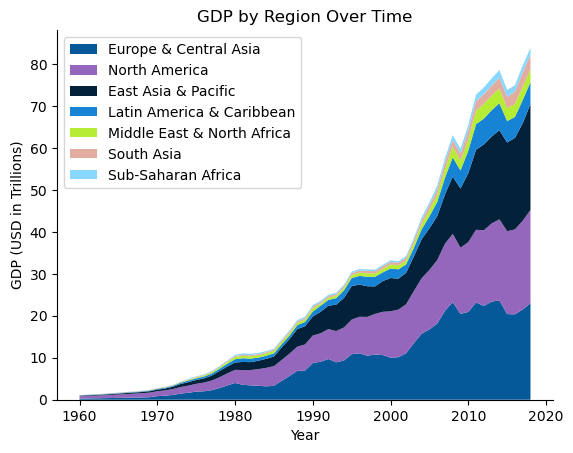

In [13]:
region_colors = ["#032239", "#065998", "#1783D5", "#B5EC34", '#9467bd', "#e3aca1", "#88D7FF"]  # Added one more color
sorted_regions = gdp_pivot.sum().sort_values(ascending=False).index.tolist()

gdp_pivot_sorted = gdp_pivot[sorted_regions]
region_colors_sorted = [region_colors[gdp_pivot.columns.get_loc(r)] for r in sorted_regions]

fig, ax = plt.subplots()

ax.stackplot(
    gdp_pivot_sorted.index,
    gdp_pivot_sorted.T/1_000_000_000_000,
    labels=gdp_pivot_sorted.columns,
    colors=region_colors_sorted
)

ax.legend(loc='upper left')
ax.set_title('GDP by Region Over Time')
ax.set_ylabel('GDP (USD in Trillions)')
ax.set_xlabel('Year') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

## Task 2 - Create a stacked area chart showing the growth of population over time, with each stack representing a geographic region.

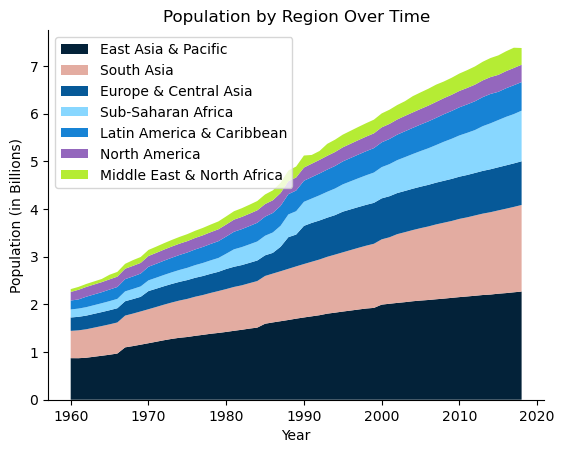

In [14]:
region_colors = ["#032239", "#065998", "#1783D5", "#B5EC34", '#9467bd', "#e3aca1", "#88D7FF"]  # Added one more color
sorted_regions = pop_pivot.sum().sort_values(ascending=False).index.tolist()

pop_pivot_sorted = pop_pivot[sorted_regions]
region_colors_sorted = [region_colors[pop_pivot.columns.get_loc(r)] for r in sorted_regions]

fig, ax = plt.subplots()

ax.stackplot(
    pop_pivot_sorted.index,
    pop_pivot_sorted.T/1_000,
    labels=pop_pivot_sorted.columns,
    colors=region_colors_sorted
)

ax.legend(loc='upper left')
ax.set_title('Population by Region Over Time')
ax.set_ylabel('Population (in Billions)')
ax.set_xlabel('Year') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

## Task 3 - Create a bubble chart with life expectancy for each country in the x-axis, GDP per capita in the y-axis (log scale), and population as the bubble size. Color the bubbles by region using the same colors for each as in the previous charts.

C:\Users\MilosIlic\AppData\Local\Temp\ipykernel_11640\1012645894.py:13: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


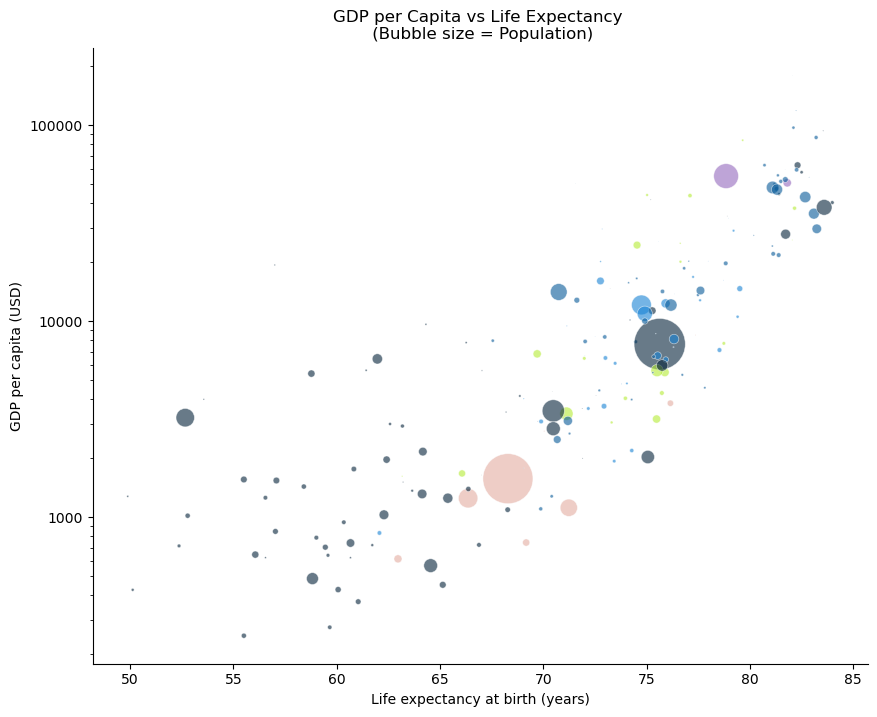

In [15]:
from matplotlib.pyplot import yscale
import matplotlib.ticker as ticker


regio_order = list(gdp_pivot.columns)
region_colors = ["#032239", "#065998", "#1783D5", "#B5EC34", "#9467bd", "#e3aca1"]

minsize = min(wb_hdi_2014['Population'])
maxsize = max(wb_hdi_2014['Population'])

fig, ax = plt.subplots(figsize=(10, 8))

sns.scatterplot(
    data=wb_hdi_2014,
    x='Life expectancy at birth (years)',
    y='GDP per capita (USD)',
    size='Population',
    sizes=(minsize, maxsize),
    hue='Region',
    hue_order=regio_order,
    palette=region_colors,
    alpha=0.6,
    edgecolor='w',
    linewidth=0.5,
    ax=ax,
    legend=False
).set(yscale='log')

ax.yaxis.set_major_formatter(ticker.ScalarFormatter())

sns.despine()

ax.set_title('GDP per Capita vs Life Expectancy \n (Bubble size = Population)')

plt.show()

## Task 4 - Create a bar chart to show average HDI by region (make sure the region colors match).

C:\Users\MilosIlic\AppData\Local\Temp\ipykernel_11640\2155241991.py:20: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(wb_hdi_by_region.index, rotation=45, ha='right')


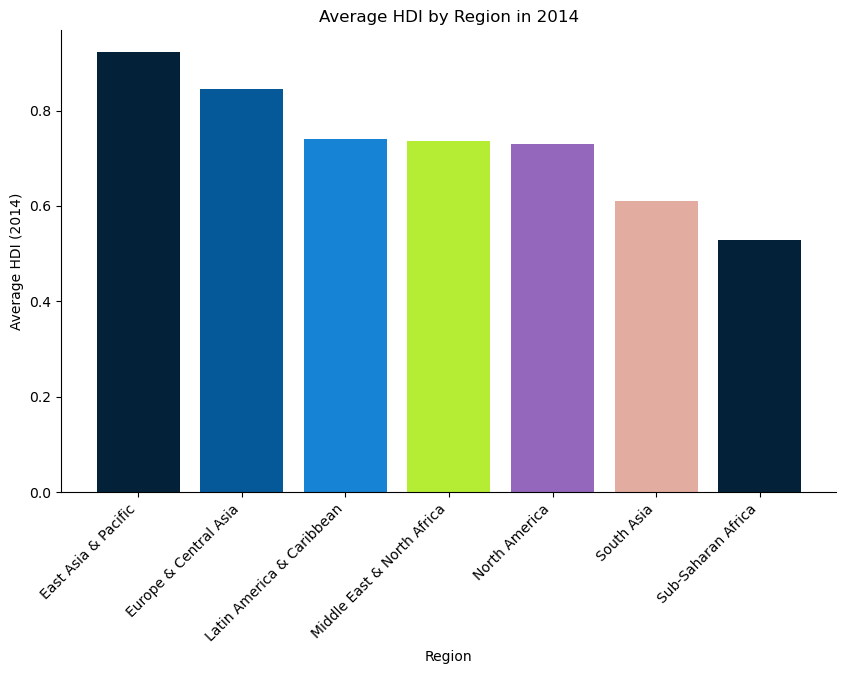

In [16]:
region_order = list(gdp_pivot.columns)

wb_hdi_by_region = wb_hdi_by_region.reindex(region_order)

region_colors = ["#032239", "#065998", "#1783D5", "#B5EC34", '#9467bd', "#e3aca1"]

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    wb_hdi_by_region.index,
    wb_hdi_by_region['avg_hdi'].sort_values(ascending=False),
    color=region_colors
)

ax.set_title('Average HDI by Region in 2014')
ax.set_ylabel('Average HDI (2014)')
ax.set_xlabel('Region')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticklabels(wb_hdi_by_region.index, rotation=45, ha='right') 

plt.show()

<Axes: title={'center': 'Average HDI by Region in 2014'}, xlabel='Region', ylabel='Human Development Index (HDI)'>

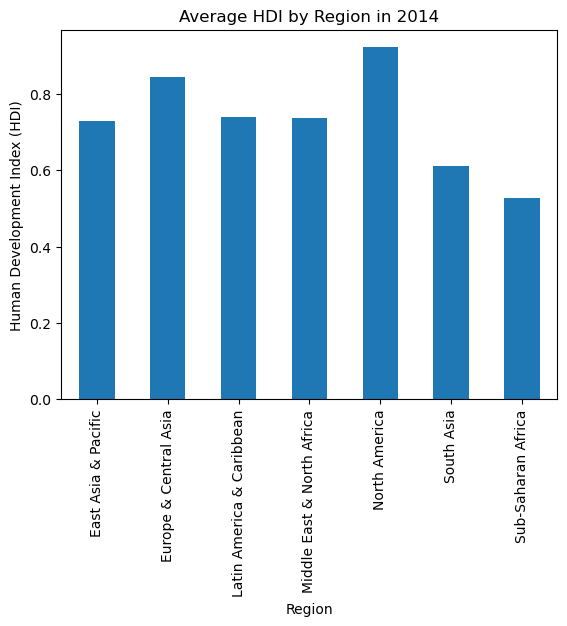

In [17]:
from matplotlib import legend


wb_hdi_by_region.plot.bar(
    title='Average HDI by Region in 2014',
    ylabel='Human Development Index (HDI)',
    legend=False
)


## Task 5 - Create a scatterplot with power consumption in the x-axis and GDP per capita in the y-axis, then use HDI as a color scale for the dots (make sure to remove outliers like Iceland).

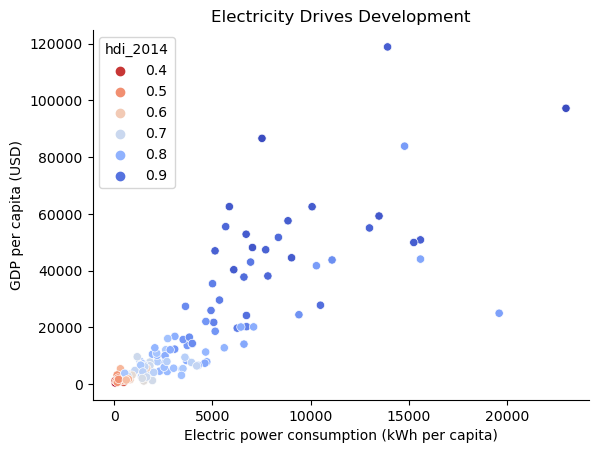

In [18]:
fig, ax = plt.subplots()

sns.scatterplot(
    data=wb_hdi_2014.query("`Country Name` != 'Iceland'"),
    x='Electric power consumption (kWh per capita)',
    y='GDP per capita (USD)',
    hue='hdi_2014',
    palette = "coolwarm_r",
    ax=ax
)

ax.set_title('Electricity Drives Development')
sns.despine()

plt.show()

# Objective 4 - Build a final report

## Task 1 - Assemble the 5 visualizations you have created into a single page (or figure).

C:\Users\MilosIlic\AppData\Local\Temp\ipykernel_11640\2366818644.py:145: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax4.set_xticklabels(wb_hdi_by_region.index, rotation=90, fontsize=8, ha='right')
C:\Users\MilosIlic\AppData\Local\Temp\ipykernel_11640\2366818644.py:186: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 0.93])


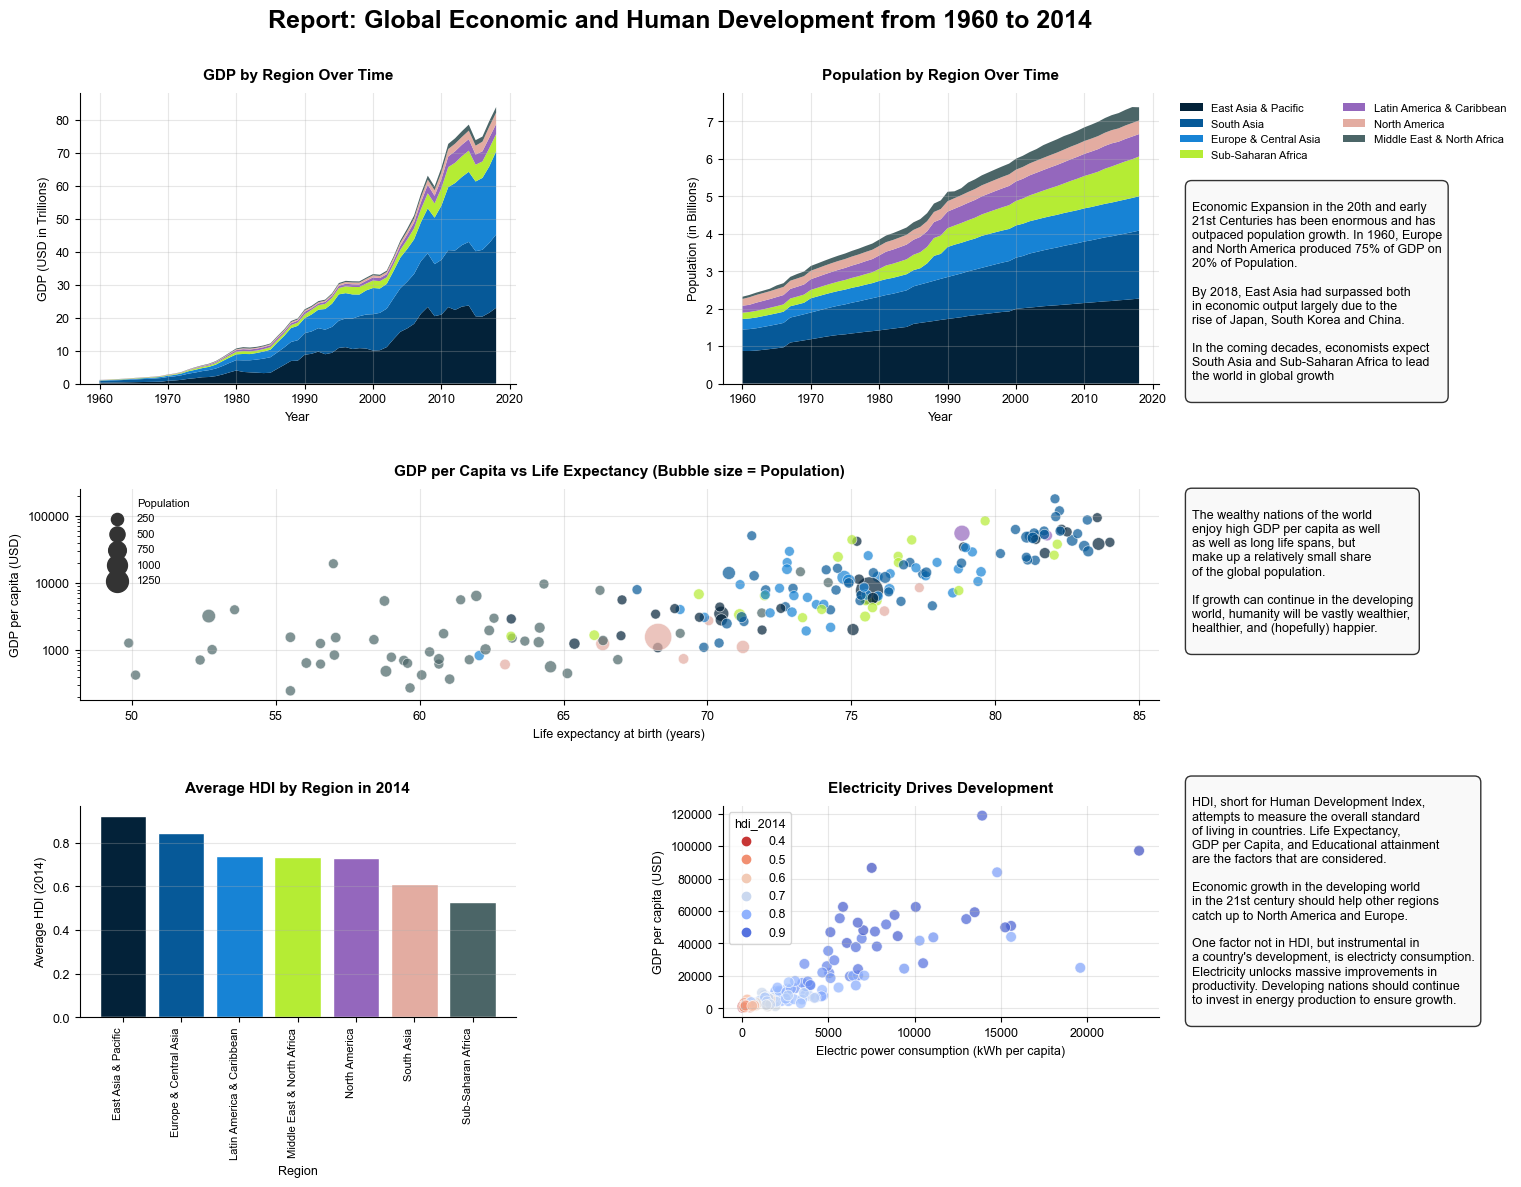

In [55]:
import matplotlib as mpl
import matplotlib.gridspec as gridspec

# Remove the unused ax parameter
fig = plt.figure(figsize=(16, 12))

gs = gridspec.GridSpec(ncols=8, nrows=12, hspace=0.5, wspace=0.4)

mpl.rcParams['font.family'] = 'Arial'

stack1_list = ["#032239", "#065998", "#1783D5", "#B5EC34", '#9467bd', "#e3aca1", "#4B6567"]
stack2_list = ["#032239", "#065998", "#1783D5", "#B5EC34", '#9467bd', "#e3aca1", "#4B6567"]
bar_list = ["#032239", "#065998", "#1783D5", "#B5EC34", '#9467bd', "#e3aca1", "#4B6567"]
bubble_list = ["#032239", "#065998", "#1783D5", "#B5EC34", '#9467bd', "#e3aca1", "#4B6567"]  

fig.patch.set_facecolor('white')

fig.suptitle(
    'Report: Global Economic and Human Development from 1960 to 2014',
    fontsize=18,
    fontweight='bold',
    y=0.95,
    x=0.5
)

# GDP Chart
ax1 = fig.add_subplot(gs[0:4, 0:3])
ax1.stackplot(
    gdp_pivot_sorted.index,
    gdp_pivot_sorted.T/1_000_000_000_000,
    labels=gdp_pivot_sorted.columns,
    colors=stack1_list
)
ax1.set_title('GDP by Region Over Time', fontsize=11, fontweight='bold', pad=10)
ax1.set_ylabel('GDP (USD in Trillions)', fontsize=9)
ax1.set_xlabel('Year', fontsize=9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(True, alpha=0.3)

# Population Chart
ax2 = fig.add_subplot(gs[0:4, 4:7])
ax2.stackplot(
    pop_pivot_sorted.index,
    pop_pivot_sorted.T/1_000,
    labels=pop_pivot_sorted.columns,
    colors=stack2_list
)

ax2.legend(bbox_to_anchor=(1.82, 1), fontsize=8, frameon=False, ncol=2)
ax2.set_title('Population by Region Over Time', fontsize=11, fontweight='bold', pad=10)
ax2.set_ylabel('Population (in Billions)', fontsize=9)
ax2.set_xlabel('Year', fontsize=9) 
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(True, alpha=0.3)

fig.text(0.82, 0.63,
'''
Economic Expansion in the 20th and early
21st Centuries has been enormous and has
outpaced population growth. In 1960, Europe
and North America produced 75% of GDP on
20% of Population.

By 2018, East Asia had surpassed both
in economic output largely due to the
rise of Japan, South Korea and China.

In the coming decades, economists expect
South Asia and Sub-Saharan Africa to lead
the world in global growth
'''
, fontsize=9, bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f8f8", alpha=0.8))

# Bubble Chart 
ax3 = fig.add_subplot(gs[5:8, 0:7]) 
sns.scatterplot(
    data=wb_hdi_2014,
    x='Life expectancy at birth (years)',
    y='GDP per capita (USD)',
    size='Population',
    sizes=(50, 400),
    hue='Region',
    hue_order=regio_order,
    palette=bubble_list,
    alpha=0.7,
    edgecolor='w',
    linewidth=0.5,
    ax=ax3
).set(yscale='log')
ax3.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax3.set_title('GDP per Capita vs Life Expectancy (Bubble size = Population)', 
              fontsize=11, fontweight='bold', pad=10)
ax3.grid(True, alpha=0.3)
sns.despine()

handles, labels = ax3.get_legend_handles_labels()
entries_to_skip = len(wb_hdi_2014['Region'].unique())+1 

for h in handles[1:]:
    sizes = [s / 1.5 for s in h.get_sizes()]
    h.set_sizes(sizes)


ax3.legend(
    handles[entries_to_skip:], 
    labels[entries_to_skip:], 
    bbox_to_anchor=(0.02, 0.98), 
    loc='upper left',
    borderaxespad=0.,
    frameon=False,
    fontsize=8
)

fig.text(0.82, 0.42,
'''
The wealthy nations of the world
enjoy high GDP per capita as well
as well as long life spans, but
make up a relatively small share
of the global population.

If growth can continue in the developing
world, humanity will be vastly wealthier,
healthier, and (hopefully) happier.
'''
, fontsize=9, 
bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f8f8", alpha=0.8))

# HDI Bar Chart
ax4 = fig.add_subplot(gs[9:12, 0:3])
ax4.bar(
    wb_hdi_by_region.index,
    wb_hdi_by_region['avg_hdi'].sort_values(ascending=False),
    color=bar_list,
    edgecolor='white',
    linewidth=1
)
ax4.set_title('Average HDI by Region in 2014', fontsize=11, fontweight='bold', pad=10)
ax4.set_ylabel('Average HDI (2014)', fontsize=9)
ax4.set_xlabel('Region', fontsize=9)
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.set_xticklabels(wb_hdi_by_region.index, rotation=90, fontsize=8, ha='right')
ax4.grid(True, alpha=0.3, axis='y')

# Electricity Chart
ax5 = fig.add_subplot(gs[9:12, 4:7])
sns.scatterplot(
    data=wb_hdi_2014.query("`Country Name` != 'Iceland'"),
    x='Electric power consumption (kWh per capita)',
    y='GDP per capita (USD)',
    hue='hdi_2014',
    palette="coolwarm_r",
    ax=ax5,
    s=60,
    alpha=0.7
)
ax5.set_title('Electricity Drives Development', fontsize=11, fontweight='bold', pad=10)
ax5.grid(True, alpha=0.3)

sns.despine()

fig.text(0.82, 0.11,
'''
HDI, short for Human Development Index,
attempts to measure the overall standard
of living in countries. Life Expectancy,
GDP per Capita, and Educational attainment
are the factors that are considered.

Economic growth in the developing world
in the 21st century should help other regions
catch up to North America and Europe.

One factor not in HDI, but instrumental in
a country's development, is electricty consumption.
Electricity unlocks massive improvements in
productivity. Developing nations should continue
to invest in energy production to ensure growth.
'''
, fontsize=9, bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f8f8", alpha=0.8))

# Use only tight_layout for cleaner spacing
plt.tight_layout(rect=[0, 0, 0.85, 0.93])  
plt.show()

# Final Question: What was the correlation between GDP per capita and HDI in the year 2014?

The correlation between GDP per capita and HDI in 2014 is: 0.6493


C:\Users\MilosIlic\AppData\Local\Temp\ipykernel_11640\3864030524.py:10: UserWarning: 
The palette list has fewer values (6) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.scatterplot(


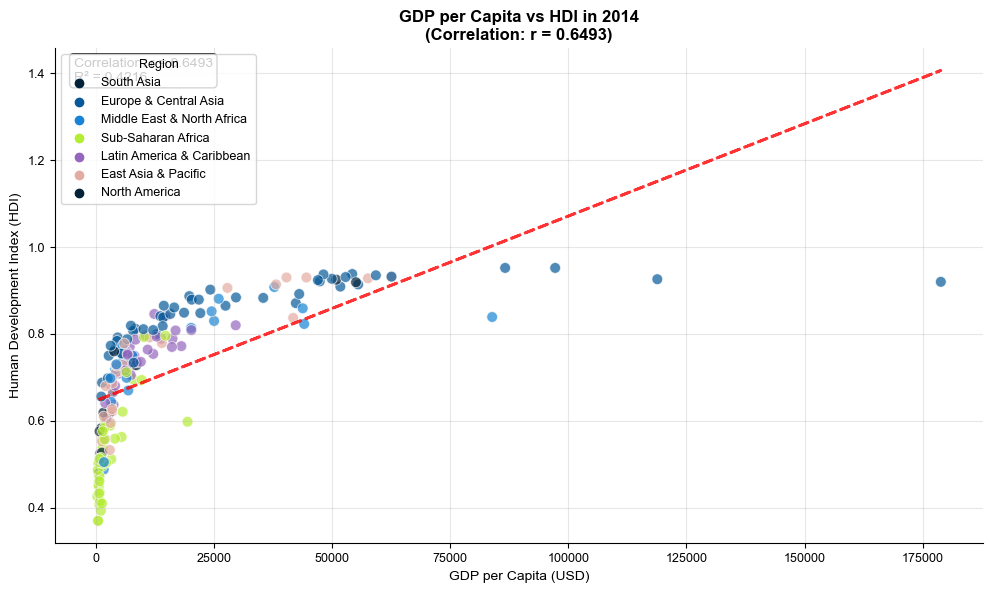


Additional Statistics:
R-squared (coefficient of determination): 0.4216
P-value: 1.20e-23
Standard error: 0.000000
Number of countries with both GDP per capita and HDI data: 186


In [ ]:
# Correlation between GDP per capita and HDI in 2014
correlation = wb_hdi_2014['GDP per capita (USD)'].corr(wb_hdi_2014['hdi_2014'])

print(f"The correlation between GDP per capita and HDI in 2014 is: {correlation:.4f}")

# Visualization to show this relationship
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot
sns.scatterplot(
    data=wb_hdi_2014.dropna(subset=['GDP per capita (USD)', 'hdi_2014']),
    x='GDP per capita (USD)',
    y='hdi_2014',
    hue='Region',
    palette=["#032239", "#065998", "#1783D5", "#B5EC34", '#9467bd', "#e3aca1"],
    alpha=0.7,
    s=60,
    ax=ax
)

# Add trend line
from scipy import stats
x = wb_hdi_2014['GDP per capita (USD)'].dropna()
y = wb_hdi_2014['hdi_2014'].dropna()
# Filter arrays
valid_data = wb_hdi_2014[['GDP per capita (USD)', 'hdi_2014']].dropna()
slope, intercept, r_value, p_value, std_err = stats.linregress(valid_data['GDP per capita (USD)'], valid_data['hdi_2014'])
line = slope * valid_data['GDP per capita (USD)'] + intercept
ax.plot(valid_data['GDP per capita (USD)'], line, 'r--', alpha=0.8, linewidth=2)

ax.set_title(f'GDP per Capita vs HDI in 2014\n(Correlation: r = {correlation:.4f})', 
             fontsize=12, fontweight='bold')
ax.set_xlabel('GDP per Capita (USD)', fontsize=10)
ax.set_ylabel('Human Development Index (HDI)', fontsize=10)
ax.grid(True, alpha=0.3)

# Correlation text box
ax.text(0.02, 0.98, f'Correlation: r = {correlation:.4f}\nR² = {r_value**2:.4f}', 
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8),
        verticalalignment='top')

sns.despine()
plt.tight_layout()
plt.show()

# Additional analysis
print(f"\nAdditional Statistics:")
print(f"R-squared (coefficient of determination): {r_value**2:.4f}")
print(f"P-value: {p_value:.2e}")
print(f"Standard error: {std_err:.6f}")

# Count of valid observations
valid_count = wb_hdi_2014[['GDP per capita (USD)', 'hdi_2014']].dropna().shape[0]
print(f"Number of countries with both GDP per capita and HDI data: {valid_count}")